#1.Імпорт всіх необхідних бібліотек

In [ ]:
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from pathlib import Path
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import importlib
import src.evaluation
importlib.reload(src.evaluation)
from src.evaluation import evaluate_model, plot_cm
import src.preprocessing
from src.preprocessing import preprocess_news_data

In [ ]:
!pip install -q sentence-transformers

In [ ]:
pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.4f}'.format)
pd.set_option("display.max_colwidth",None)

warnings.filterwarnings('ignore')

#2. Завантаження первинних даних

In [ ]:
train_df = pd.read_csv("data/train.csv.zip")
valid_df = pd.read_csv("data/valid.csv.zip")
test_df = pd.read_csv("data/test.csv.zip")

X_train = train_df["text"]
y_train = train_df["category"]

X_valid = valid_df["text"]
y_valid = valid_df["category"]

X_test = test_df["text"]
y_test = test_df["category"]


#3. Векторизація тексту (SentenceTransformer)

SentenceTransformer використовується для отримання семантичних векторних представлень тексту (embeddings), після чого класифікація виконується за допомогою Logistic Regression. Такий підхід дозволить використати контекстні представлення тексту, які є більш інформативними порівняно з TF-IDF.

In [ ]:
start = time.time()

embedder = SentenceTransformer("all-MiniLM-L6-v2")

X_train_emb = embedder.encode(
    X_train.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

X_valid_emb = embedder.encode(
    X_valid.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

X_test_emb = embedder.encode(
    X_test.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2287 [00:00<?, ?it/s]

Batches:   0%|          | 0/490 [00:00<?, ?it/s]

Batches:   0%|          | 0/490 [00:00<?, ?it/s]

In [ ]:
print("Train:", X_train_emb.shape)
print("Validation:", X_valid_emb.shape)
print("Test:", X_test_emb.shape)

Train: (146335, 384)
Validation: (31358, 384)
Test: (31358, 384)


#4. Побудова SentenceTransformer + LogisticRegression -моделі

In [ ]:
st_model = LogisticRegression(
    random_state=42,
    max_iter=3000,
    n_jobs=-1
)

st_model.fit(X_train_emb, y_train)
training_time = time.time() - start

formatted_time = time.strftime(
    "%H:%M:%S",
    time.gmtime(training_time)
)

print(f"Час навчання: {formatted_time}")

Час навчання: 00:03:27


# 5. Оцінка SentenceTransformer + LogisticRegression -моделі

##5.1 Розрахунок передбачень

In [ ]:
train_accuracy, train_macro_f1, train_weighted_f1, y_train_pred = evaluate_model(
    st_model,
    X_train_emb,
    y_train
)
valid_accuracy, valid_macro_f1, valid_weighted_f1,  y_valid_pred = evaluate_model(
    st_model,
    X_valid_emb,
    y_valid
)

##5.2 Порівняння метрик

Основною метрикою оцінювання моделей обрано Macro F1-score, оскільки задача є багатокласовою класифікацією з незбалансованим розподілом класів. Ця метрика дозволяє оцінити якість моделі для всіх категорій незалежно від їх розміру.  

В якості допоміжних метрик обрано:
* Accuracy - показує загальну частку правильних прогнозів.
* Weighted F1-score - вона враховує дисбаланс класів.

Проведемо порівняння метрик:

In [ ]:
results = pd.DataFrame({
    "Dataset": ["Train", "Validation"],
    "Accuracy": [train_accuracy, valid_accuracy],
    "Macro F1": [train_macro_f1, valid_macro_f1],
    "Weighted F1": [train_weighted_f1, valid_weighted_f1]
})
results

,Dataset,Accuracy,Macro F1,Weighted F1
0,Train,0.6254,0.5015,0.6072
1,Validation,0.6118,0.4763,0.5911


***Висновок:***
* Порівнюючи значення метрик accuracy та Macro F1-score на тренувальному та  валідаційному наборах даних, можна зробити висновок про перенавчання побудованої базової моделі Logistic Regression з TF-IDF.

##5.3 Детальний classification report

Побудуємо детальний звіт для тестовго та валідаційного наборів даних:

In [ ]:
print(classification_report(y_train, y_train_pred))

                precision    recall  f1-score   support

          ARTS       0.46      0.33      0.38      1056
ARTS & CULTURE       0.43      0.23      0.29       937
  BLACK VOICES       0.52      0.37      0.43      3206
      BUSINESS       0.52      0.50      0.51      4192
       COLLEGE       0.53      0.44      0.48       801
        COMEDY       0.50      0.38      0.43      3773
         CRIME       0.55      0.61      0.58      2490
CULTURE & ARTS       0.54      0.32      0.40       751
       DIVORCE       0.77      0.73      0.75      2396
     EDUCATION       0.53      0.41      0.47       710
 ENTERTAINMENT       0.61      0.75      0.67     12150
   ENVIRONMENT       0.54      0.27      0.36      1010
         FIFTY       0.47      0.23      0.30       981
  FOOD & DRINK       0.64      0.81      0.71      4438
     GOOD NEWS       0.41      0.26      0.32       979
         GREEN       0.43      0.44      0.43      1832
HEALTHY LIVING       0.49      0.22      0.31  

In [ ]:
print(classification_report(y_valid, y_valid_pred))

                precision    recall  f1-score   support

          ARTS       0.36      0.21      0.27       227
ARTS & CULTURE       0.33      0.19      0.24       201
  BLACK VOICES       0.53      0.34      0.42       687
      BUSINESS       0.53      0.48      0.50       899
       COLLEGE       0.54      0.44      0.49       171
        COMEDY       0.49      0.37      0.42       809
         CRIME       0.53      0.58      0.55       534
CULTURE & ARTS       0.46      0.29      0.35       161
       DIVORCE       0.77      0.71      0.74       514
     EDUCATION       0.47      0.39      0.43       152
 ENTERTAINMENT       0.60      0.77      0.67      2604
   ENVIRONMENT       0.48      0.24      0.32       216
         FIFTY       0.42      0.20      0.27       210
  FOOD & DRINK       0.63      0.80      0.71       951
     GOOD NEWS       0.40      0.23      0.29       209
         GREEN       0.40      0.40      0.40       393
HEALTHY LIVING       0.45      0.20      0.27  

***Висновки:***

* Модель демонструє стабільні результати на тренувальному та валідаційному наборах даних. Різниця між основними метриками (Accuracy, Macro F1 та Weighted F1) є незначною, що свідчить про відсутність суттєвого перенавчання та хорошу здатність моделі узагальнювати нові дані.

* Найкращі результати модель показує для категорій із чітко вираженою тематикою, зокрема POLITICS, WEDDINGS, STYLE & BEAUTY, TRAVEL, SPORTS та FOOD & DRINK. Водночас нижчі значення F1 спостерігаються для категорій зі схожим змістом, таких як HEALTHY LIVING, WELLNESS, PARENTS, PARENTING, TASTE та FOOD & DRINK, що пояснюється їхньою високою семантичною близькістю.

# 6. Аналіз результатів baseline-моделі

##6.1 Матриця помилок

Побудуємо нормалізовану матрицю помилок навчального та валідаційного наборів даних:

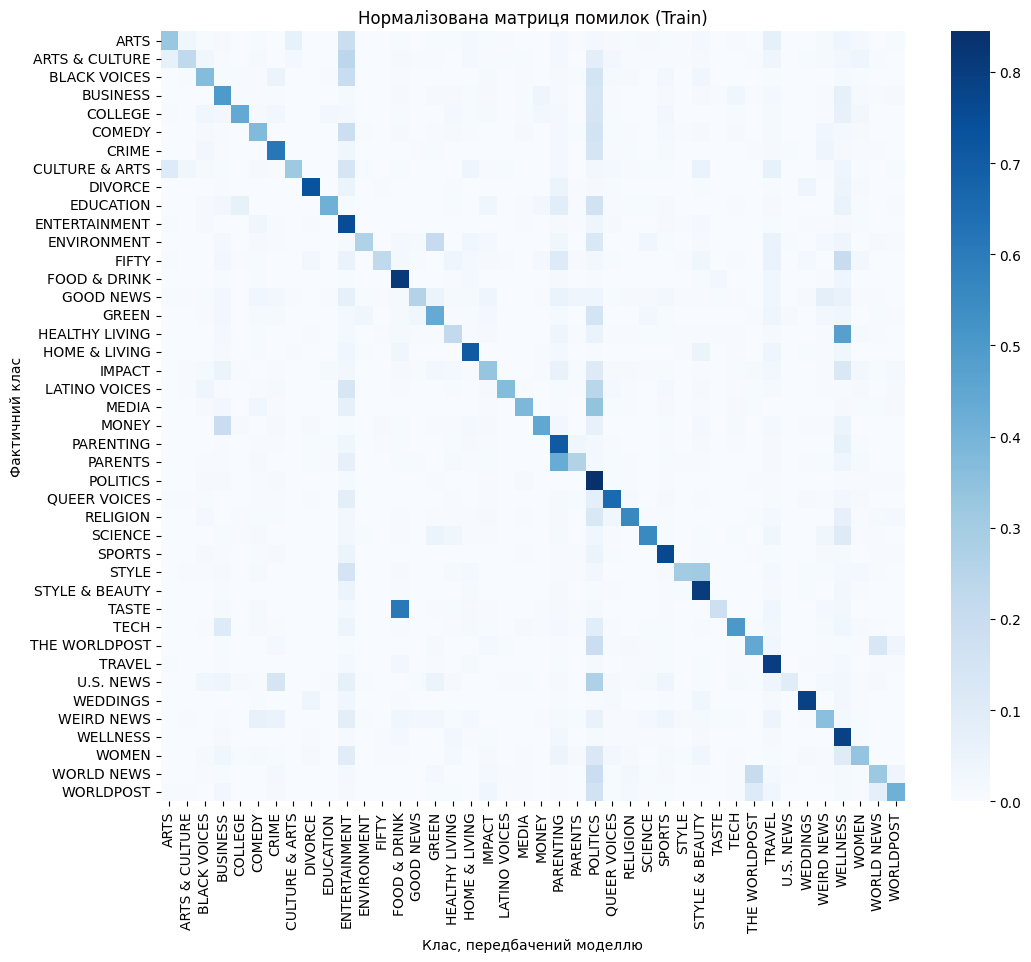

In [ ]:
plot_cm(y_train, y_train_pred, "Train")

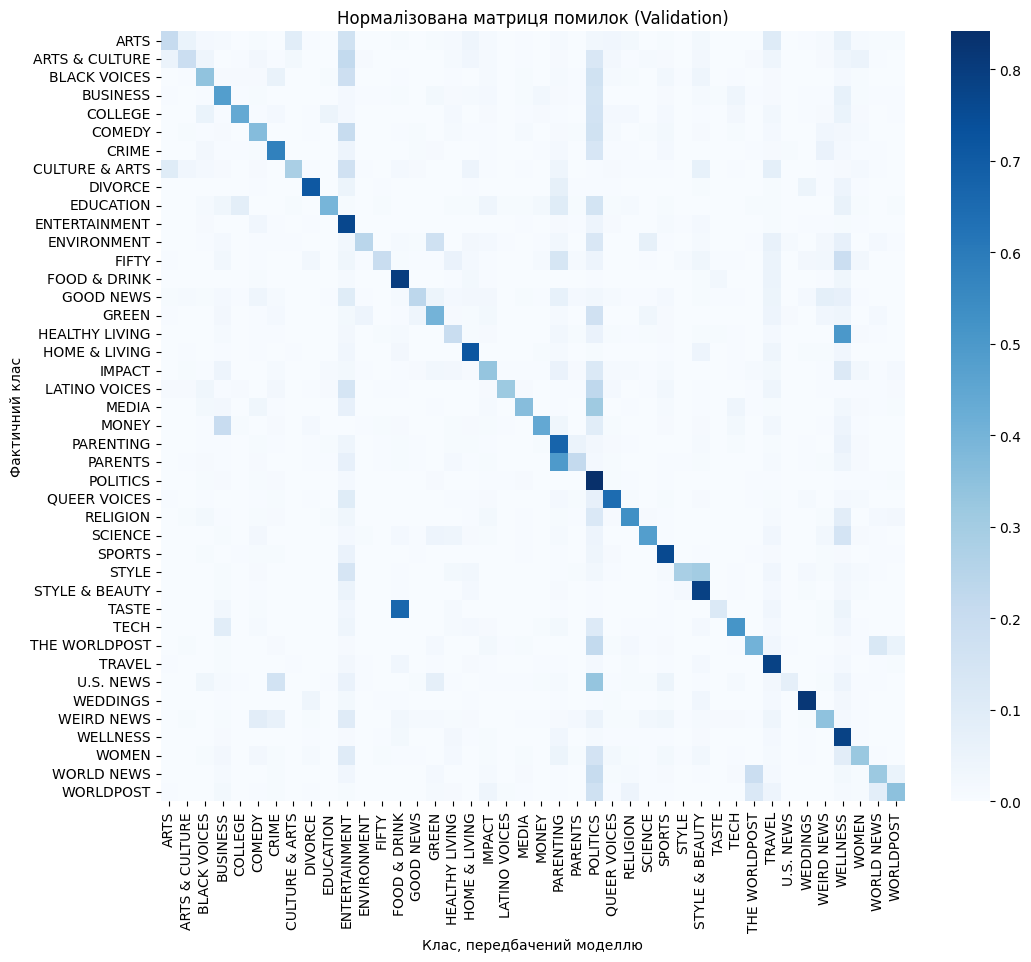

In [ ]:
plot_cm(y_valid, y_valid_pred, "Validation")

***Висновки:***
* Загалом нормалізовані матриці помилок для тренувального та валідаційного наборів мають подібну структуру, що свідчить про стабільну роботу моделі та відсутність суттєвого перенавчання.

* Найвищу частку правильних класифікацій демонструють категорії POLITICS, STYLE & BEAUTY, WEDDINGS, FOOD & DRINK, TRAVEL та SPORTS, для яких більшість прикладів класифікується правильно.

* Основні помилки виникають між тематично близькими категоріями. Найчастіше модель плутає HEALTHY LIVING із WELLNESS, PARENTS із PARENTING, TASTE із FOOD & DRINK, а також окремі суспільно-політичні категорії (BUSINESS, MEDIA, THE WORLDPOST) із POLITICS. Це пояснюється семантичною близькістю цих категорій та частковим перетином їхнього змісту.

##6.2 Аналіз помилок моделі

In [ ]:
errors = pd.DataFrame({
    "text": X_valid,
    "true_category": y_valid,
    "predicted_category": y_valid_pred
})

errors = errors[
    errors["true_category"] != errors["predicted_category"]
]

errors.head(20)

,text,true_category,predicted_category
2,"Cooking Cous Cous in Fez The sad and suspicious eyes of a decapitated sheep followed us past the fishmonger's stall and back to the kitchen. ""We'll",TRAVEL,WEIRD NEWS
9,"Women Leaders in (EU) Foreign Policy: will Mrs Be Better than Lady? On Halloween night, the European Commission -- Europe's ""executive"" -- changed. At the helm of foreign policy, Lady PESC -- as Catherine Ashton was known -- gave way to Mrs PESC, as Federica Mogherini prefers to be called. Two different women leaders, two leadership styles in foreign policy.",WOMEN,POLITICS
10,5 Benefits Of Having A Friend With Benefits Who doesn't feel glorious when the sex between you and your partner is fantastic? Some of us believe that friends with benefits,DIVORCE,WELLNESS
15,"These Images From A Burning Gatlinburg, Tennessee, Are Terrifying A massive wildfire has forced evacuations in areas around Great Smoky Mountains National Park.",GREEN,TRAVEL
19,"The Very Best Anti-Aging Skin Strategy Yesterday morning, I woke up ridiculously late, like 10 am, feeling like a prizefighter who had taken in the full 15 rounds. It felt great to sleep in -- 'this must be what the kids feel like -- late nights -- deep long sleeps -- delish.' Splashing refreshing cold water on my face -- I looked up and I caught a glimpse of -- someone else?",FIFTY,WELLNESS
20,Why Does Your Dog Cock Its Head? Is Head-Tilting a Sign of Intelligence? Or Something Else? Or is she? What’s really happening when your dog tilts her head,ENVIRONMENT,BUSINESS
21,"Meet A Facebook Bounty Hunter Who Takes Down Impostor Accounts, For A Fee Celebrities, CEOs and preachers pay Kevin Long thousands of dollars a month to hunt down online fakers.",TECH,ENTERTAINMENT
24,"Medicine For Another Day A “new era” in medicine does not come along very often. We had one, perhaps, in 1854 when John Snow effectively invented",HEALTHY LIVING,WELLNESS
26,"This Law Lets Abused Animals Get Their Own Advocates In Court Connecticut is the first state to pass this kind of legislation, a professor says.",CRIME,POLITICS
34,UN Widens Probe Of Fresh Sex Abuse Allegations In Central African Republic A team led by the U.N. peacekeeping mission in CAR has traveled to the Kemo prefecture to investigate.,THE WORLDPOST,WORLD NEWS


In [ ]:
print(f"Кількість помилок: {len(errors)}")
print(f"Частка помилок: {len(errors) / len(y_valid):.2%}")

Кількість помилок: 12173
Частка помилок: 38.82%


In [ ]:
errors_pairs = (
    errors
    .groupby(["true_category", "predicted_category"])
    .size()
    .sort_values(ascending=False)
)

errors_pairs.head(15)

,,0
true_category,predicted_category,
HEALTHY LIVING,WELLNESS,503
PARENTS,PARENTING,289
TASTE,FOOD & DRINK,208
COMEDY,ENTERTAINMENT,166
MEDIA,POLITICS,139
BUSINESS,POLITICS,138
COMEDY,POLITICS,133
BLACK VOICES,ENTERTAINMENT,125
THE WORLDPOST,POLITICS,120


***Висновки:***

* Аналіз помилок моделі показує, що більшість неправильних прогнозів виникає між тематично близькими категоріями. Найбільша кількість помилок спостерігається для пар HEALTHY LIVING – WELLNESS, PARENTS – PARENTING, TASTE – FOOD & DRINK, а також для новинних категорій, які модель часто відносить до POLITICS. Це свідчить про значну семантичну схожість відповідних категорій та складність їх чіткого розмежування.

#7. Збереження моделі

In [ ]:
import os

os.makedirs("models", exist_ok=True)
joblib.dump(st_model, "models/sentence_transformer_logreg.joblib")

['models/sentence_transformer_logreg.joblib']